# 🚀 Gold Price Prediction Pipeline (Fixed)

แก้ไขบั๊ก `ValueError: Input X contains infinity` ที่เกิดจาก `pct_change()` สร้างค่า `inf` เมื่อค่าก่อนหน้าเป็น 0 (เช่น `Gold_Volume` ที่บางแท่งเป็น 0) โดยเพิ่มการแทนที่ `inf`/`-inf` ด้วย `NaN` ก่อน `dropna()` ใน `create_features()` และเพิ่มการตรวจสอบ (`assert`) ก่อนเข้า `SelectKBest`

## 📦 Cell 1: Imports

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("Libraries loaded.")

Libraries loaded.


## 📊 Cell 2: STEP 1 — Data Collection

In [31]:
print("=" * 80)
print("📊 STEP 1: DATA COLLECTION")
print("=" * 80)

tickers = {'Gold': 'GC=F', 'DXY': 'DX-Y.NYB', 'VIX': '^VIX', 'SP500': '^GSPC'}
data_dict = {}
first_index = None

for name, ticker in tickers.items():
    print(f"Downloading {name} ({ticker})...")
    df = yf.download(ticker, period='2y', interval='1h', progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if df.empty:
        print(f"⚠️ Warning: No data found for {ticker}")
        continue

    if first_index is None:
        first_index = df.index

    data_dict[f'{name}_Close'] = df['Close'].squeeze()

    if name == 'Gold':
        data_dict['Gold_High'] = df['High'].squeeze()
        data_dict['Gold_Low'] = df['Low'].squeeze()
        data_dict['Gold_Open'] = df['Open'].squeeze()
        data_dict['Gold_Volume'] = df['Volume'].squeeze()

data = pd.DataFrame(data_dict, index=first_index).ffill().dropna()
print(f"✅ Data loaded successfully. Shape: {data.shape}")

# ตรวจสอบสัดส่วนแท่งที่ Volume = 0 (ต้นตอของ inf ใน pct_change)
zero_vol_ratio = (data['Gold_Volume'] == 0).mean()
print(f"ℹ️ สัดส่วนแท่งที่ Gold_Volume = 0: {zero_vol_ratio:.2%}")

📊 STEP 1: DATA COLLECTION
✅ Data loaded successfully. Shape: (10390, 8)
ℹ️ สัดส่วนแท่งที่ Gold_Volume = 0: 3.52%


In [32]:
# ================= 💾 SAVE DATA TO CSV =================
print("\n💾 Saving data splits to CSV...")

os.makedirs('data', exist_ok=True)

# แปลงกลับเป็น DataFrame เพื่อ save
def sequence_to_df(X_seq, y_seq, feature_names, start_idx):
    """แปลง sequence กลับเป็น DataFrame แบบ row-per-sample"""
    # ใช้ข้อมูลล่าสุดของ sequence (timestep สุดท้าย) เป็นตัวแทน
    last_timestep = X_seq[:, -1, :]  # shape: (n_samples, n_features)
    df = pd.DataFrame(last_timestep, columns=feature_names)
    df['Target'] = y_seq
    df['Original_Index'] = range(start_idx, start_idx + len(y_seq))
    return df

# คำนวณ index เริ่มต้นของแต่ละ set
train_start = 0
val_start = len(y_train)
test_start = len(y_train) + len(y_val)

# Save แต่ละ set
train_df = sequence_to_df(X_train, y_train, selected_feature_names, train_start)
val_df = sequence_to_df(X_val, y_val, selected_feature_names, val_start)
test_df = sequence_to_df(X_test, y_test, selected_feature_names, test_start)

train_df.to_csv('data/train_data.csv', index=False)
val_df.to_csv('data/val_data.csv', index=False)
test_df.to_csv('data/test_data.csv', index=False)

# Save ข้อมูลดิบ (ก่อน feature selection) ด้วย
df_features.to_csv('data/full_features.csv')
data.to_csv('data/raw_data.csv')

print(f"✅ Saved to data/ folder:")
print(f"   📄 train_data.csv: {len(train_df)} rows")
print(f"   📄 val_data.csv:   {len(val_df)} rows")
print(f"   📄 test_data.csv:  {len(test_df)} rows")
print(f"   📄 full_features.csv: {len(df_features)} rows")
print(f"   📄 raw_data.csv: {len(data)} rows")


💾 Saving data splits to CSV...
✅ Saved to data/ folder:
   📄 train_data.csv: 8133 rows
   📄 val_data.csv:   1017 rows
   📄 test_data.csv:  1017 rows
   📄 full_features.csv: 10191 rows
   📄 raw_data.csv: 10390 rows


## 🔧 Cell 3: STEP 2 — ICT Pattern Functions (FVG / Order Block / BOS-CHoCH)

In [20]:
def detect_fvg(df):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values

    bullish_fvg = np.zeros(len(df))
    bearish_fvg = np.zeros(len(df))
    fvg_size = np.zeros(len(df))

    for i in range(2, len(df)):
        if low[i] > high[i-2]:
            bullish_fvg[i] = 1
            fvg_size[i] = low[i] - high[i-2]
        elif high[i] < low[i-2]:
            bearish_fvg[i] = 1
            fvg_size[i] = low[i-2] - high[i]

    return pd.DataFrame({
        'Bullish_FVG': bullish_fvg,
        'Bearish_FVG': bearish_fvg,
        'FVG_Size': fvg_size,
        'FVG_Net': bullish_fvg - bearish_fvg
    }, index=df.index)


def detect_order_block(df, lookback=10):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values
    open_price = df['Gold_Open'].values

    bullish_ob = np.zeros(len(df))
    bearish_ob = np.zeros(len(df))

    for i in range(lookback, len(df)):
        swing_high = np.max(high[i-lookback:i])
        swing_low = np.min(low[i-lookback:i])

        if close[i] > open_price[i] and close[i] > swing_high:
            for j in range(i-1, max(i-lookback, 0), -1):
                if close[j] < open_price[j]:
                    bullish_ob[i] = 1
                    break
        elif close[i] < open_price[i] and close[i] < swing_low:
            for j in range(i-1, max(i-lookback, 0), -1):
                if close[j] > open_price[j]:
                    bearish_ob[i] = 1
                    break

    return pd.DataFrame({
        'Bullish_OB': bullish_ob,
        'Bearish_OB': bearish_ob,
        'OB_Net': bullish_ob - bearish_ob
    }, index=df.index)


def detect_bos_choch(df, lookback=20):
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values

    bos_bullish = np.zeros(len(df))
    bos_bearish = np.zeros(len(df))
    choch_bullish = np.zeros(len(df))
    choch_bearish = np.zeros(len(df))

    for i in range(lookback, len(df)):
        swing_high = np.max(high[i-lookback:i-1])
        swing_low = np.min(low[i-lookback:i-1])
        prev_trend = np.polyfit(range(lookback), close[i-lookback:i], 1)[0]

        if close[i] > swing_high and prev_trend > 0:
            bos_bullish[i] = 1
        elif close[i] < swing_low and prev_trend < 0:
            bos_bearish[i] = 1
        elif close[i] > swing_high and prev_trend < 0:
            choch_bullish[i] = 1
        elif close[i] < swing_low and prev_trend > 0:
            choch_bearish[i] = 1

    return pd.DataFrame({
        'BOS_Bullish': bos_bullish,
        'BOS_Bearish': bos_bearish,
        'CHoCH_Bullish': choch_bullish,
        'CHoCH_Bearish': choch_bearish,
        'Structure_Score': (bos_bullish + choch_bullish) - (bos_bearish + choch_bearish)
    }, index=df.index)


def detect_candle_patterns(df):
    open_price = df['Gold_Open'].values
    high = df['Gold_High'].values
    low = df['Gold_Low'].values
    close = df['Gold_Close'].values

    body = np.abs(close - open_price)
    upper_shadow = high - np.maximum(open_price, close)
    lower_shadow = np.minimum(open_price, close) - low
    total_range = high - low
    total_range = np.where(total_range == 0, 1e-10, total_range)

    patterns = {}

    bullish_engulfing = np.zeros(len(df))
    bearish_engulfing = np.zeros(len(df))
    for i in range(1, len(df)):
        if (close[i-1] < open_price[i-1] and close[i] > open_price[i] and
            body[i] > body[i-1] and open_price[i] <= close[i-1] and close[i] >= open_price[i-1]):
            bullish_engulfing[i] = 1
        elif (close[i-1] > open_price[i-1] and close[i] < open_price[i] and
              body[i] > body[i-1] and open_price[i] >= close[i-1] and close[i] <= open_price[i-1]):
            bearish_engulfing[i] = 1

    patterns['Bullish_Engulfing'] = bullish_engulfing
    patterns['Bearish_Engulfing'] = bearish_engulfing

    hammer = np.zeros(len(df))
    shooting_star = np.zeros(len(df))
    for i in range(len(df)):
        if (lower_shadow[i] > 2 * body[i] and upper_shadow[i] < body[i] and body[i] > 0):
            hammer[i] = 1
        elif (upper_shadow[i] > 2 * body[i] and lower_shadow[i] < body[i] and body[i] > 0):
            shooting_star[i] = 1

    patterns['Hammer'] = hammer
    patterns['Shooting_Star'] = shooting_star
    patterns['Doji'] = np.where(body < 0.1 * total_range, 1, 0)

    inside_bar = np.zeros(len(df))
    outside_bar = np.zeros(len(df))
    for i in range(1, len(df)):
        if high[i] < high[i-1] and low[i] > low[i-1]:
            inside_bar[i] = 1
        if high[i] > high[i-1] and low[i] < low[i-1]:
            outside_bar[i] = 1

    patterns['Inside_Bar'] = inside_bar
    patterns['Outside_Bar'] = outside_bar
    patterns['Body_Ratio'] = body / total_range
    patterns['Upper_Shadow_Ratio'] = upper_shadow / total_range
    patterns['Lower_Shadow_Ratio'] = lower_shadow / total_range

    return pd.DataFrame(patterns, index=df.index)

print("ICT / candlestick pattern functions defined.")

ICT / candlestick pattern functions defined.


## 🔧 Cell 4: STEP 2 — Feature Engineering (`create_features`) — **แก้บั๊ก inf ตรงนี้**

In [21]:
def create_features(df):
    feat = df.copy()

    feat['Gold_RSI'] = ta.momentum.RSIIndicator(feat['Gold_Close'], window=14).rsi()
    feat['Gold_MACD'] = ta.trend.MACD(feat['Gold_Close']).macd()
    feat['Gold_BB_High'] = ta.volatility.BollingerBands(feat['Gold_Close']).bollinger_hband()
    feat['Gold_BB_Low'] = ta.volatility.BollingerBands(feat['Gold_Close']).bollinger_lband()

    feat['Gold_ATR'] = ta.volatility.AverageTrueRange(
        high=feat['Gold_High'], low=feat['Gold_Low'],
        close=feat['Gold_Close'], window=14
    ).average_true_range()

    feat['Gold_Stoch'] = ta.momentum.StochasticOscillator(
        feat['Gold_High'], feat['Gold_Low'], feat['Gold_Close']
    ).stoch()

    # ⚠️ FIX: pct_change() ให้ค่า inf เมื่อ Gold_Volume ก่อนหน้าเป็น 0
    #    -> ปัดเป็น 0 ทันทีแทนที่จะปล่อยเป็น inf
    feat['Gold_Vol_Change'] = feat['Gold_Volume'].pct_change().replace([np.inf, -np.inf], 0)

    for window in [10, 20, 50, 200]:
        feat[f'Gold_SMA_{window}'] = feat['Gold_Close'].rolling(window).mean()
        feat[f'Gold_EMA_{window}'] = feat['Gold_Close'].ewm(span=window, adjust=False).mean()

    feat['DXY_Change'] = feat['DXY_Close'].pct_change().replace([np.inf, -np.inf], 0)
    feat['VIX_Change'] = feat['VIX_Close'].pct_change().replace([np.inf, -np.inf], 0)
    feat['Gold_DXY_Corr'] = feat['Gold_Close'].rolling(20).corr(feat['DXY_Close'])

    print("🔍 Detecting ICT patterns...")
    feat = pd.concat([feat, detect_fvg(df)], axis=1)
    feat = pd.concat([feat, detect_order_block(df, lookback=10)], axis=1)
    feat = pd.concat([feat, detect_bos_choch(df, lookback=20)], axis=1)

    print("🕯️ Detecting candlestick patterns...")
    feat = pd.concat([feat, detect_candle_patterns(df)], axis=1)

    feat['FVG_Count_10'] = (feat['Bullish_FVG'] + feat['Bearish_FVG']).rolling(10).sum()
    feat['FVG_Net_10'] = feat['FVG_Net'].rolling(10).sum()
    feat['OB_Count_20'] = (feat['Bullish_OB'] + feat['Bearish_OB']).rolling(20).sum()
    feat['Structure_Events_30'] = (
        feat['BOS_Bullish'] + feat['BOS_Bearish'] +
        feat['CHoCH_Bullish'] + feat['CHoCH_Bearish']
    ).rolling(30).sum()

    future_return = feat['Gold_Close'].shift(-3) / feat['Gold_Close'] - 1
    feat['Target'] = np.select(
        [future_return > 0.001, future_return < -0.001],
        [1, -1],
        default=0
    )

    # ⚠️ FIX หลัก: กวาด inf/-inf ที่หลงเหลือ (เช่นจาก Gold_DXY_Corr หรือ rolling ที่ผิดพลาด)
    #    ให้กลายเป็น NaN ก่อน dropna() เพราะ dropna() ไม่ลบ inf ให้เอง
    feat = feat.replace([np.inf, -np.inf], np.nan)

    return feat.dropna()


df_features = create_features(data)
print(f"✅ Features created. Shape: {df_features.shape}")

🔍 Detecting ICT patterns...
🕯️ Detecting candlestick patterns...
✅ Features created. Shape: (10191, 53)


## 🎯 Cell 5: STEP 3 — Feature Selection + แก้ label mapping (Target -1/0/1 → 0/1/2)

In [22]:
print("=" * 80)
print("🎯 STEP 3: FEATURE SELECTION")
print("=" * 80)

cols_to_drop = [
    'Target', 'Gold_Close', 'Gold_High', 'Gold_Low', 'Gold_Open',
    'Gold_Volume', 'DXY_Close', 'VIX_Close', 'SP500_Close'
]
X = df_features.drop(columns=[c for c in cols_to_drop if c in df_features.columns])

# ⚠️ FIX (สำคัญ): Target เดิมมีค่า {-1, 0, 1} แต่ sparse_categorical_crossentropy
#    ต้องการ label เป็นจำนวนเต็มเริ่มจาก 0 เท่านั้น {0, 1, 2, ...}
#    -> map ตรงนี้จุดเดียว ก่อนแตกเป็น y_train/y_val/y_test ทุกตัวจะถูกต้องอัตโนมัติ
#    mapping: -1 (Down) -> 0, 0 (Neutral) -> 1, 1 (Up) -> 2
y = df_features['Target'].map({-1: 0, 0: 1, 1: 2}).astype(int)

# ⚠️ FIX: ตรวจสอบล่วงหน้าว่าไม่มี inf/NaN หลงเหลือ ก่อนเข้า SelectKBest
#    ถ้ายังมี error ตรงนี้จะบอกชัดเจนกว่า traceback ของ sklearn
assert np.isfinite(X.values).all(), "X ยังมีค่า inf หรือ NaN อยู่ - ตรวจสอบ create_features() อีกครั้ง"

k_features = min(30, X.shape[1])
print(f"📊 Total available features: {X.shape[1]}")
print(f"🎯 Selecting top {k_features} features...\n")

selector = SelectKBest(score_func=f_classif, k=k_features)
X_selected = selector.fit_transform(X, y)
selected_feature_names = X.columns[selector.get_support()].tolist()
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names, index=df_features.index)

print(f"✅ Selected Features ({len(selected_feature_names)}):")
for i, feat_name in enumerate(selected_feature_names[:10], 1):
    print(f"  {i}. {feat_name}")
if len(selected_feature_names) > 10:
    print(f"  ... and {len(selected_feature_names) - 10} more")

🎯 STEP 3: FEATURE SELECTION
📊 Total available features: 44
🎯 Selecting top 30 features...

✅ Selected Features (30):
  1. Gold_RSI
  2. Gold_MACD
  3. Gold_BB_High
  4. Gold_BB_Low
  5. Gold_ATR
  6. Gold_Stoch
  7. Gold_SMA_10
  8. Gold_EMA_10
  9. Gold_SMA_20
  10. Gold_EMA_20
  ... and 20 more


## 🚀 Cell 6: STEP 4 — สร้าง Sequences และแบ่ง Train/Val/Test

In [23]:
print("=" * 80)
print("🚀 STEP 4: MODEL BUILDING & TRAINING")
print("=" * 80)

def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 24
print(f"📊 Creating sequences with time_steps={time_steps}...")
X_seq, y_seq = create_sequences(X_selected_df, y, time_steps)

split_idx = int(len(X_seq) * 0.8)
val_idx = int(len(X_seq) * 0.9)

X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_val, y_val = X_seq[split_idx:val_idx], y_seq[split_idx:val_idx]
X_test, y_test = X_seq[val_idx:], y_seq[val_idx:]

print(f"📈 Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

🚀 STEP 4: MODEL BUILDING & TRAINING
📊 Creating sequences with time_steps=24...
📈 Train: 8133, Val: 1017, Test: 1017


## ⚖️ Cell 7: Scaling + Class Weights

In [24]:
scaler = MinMaxScaler(feature_range=(0, 1))
n_samples, n_timesteps, n_features = X_train.shape
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(n_samples, n_timesteps, n_features)
X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape[0], n_timesteps, n_features)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape[0], n_timesteps, n_features)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(cls): weight for cls, weight in zip(np.unique(y_train), class_weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.977994227994228), 1: np.float64(1.3561780890445223), 2: np.float64(0.806365258774539)}


## 🧠 Cell 8: นิยามโมเดล LSTM / BiLSTM

In [25]:
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, activation='relu', return_sequences=True),
        Dropout(0.3),
        LSTM(32, activation='relu', return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, activation='relu', return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32, activation='relu', return_sequences=False)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

input_shape = (time_steps, n_features)
lstm_model = build_lstm(input_shape)
bilstm_model = build_bilstm(input_shape)


early_stopping = EarlyStopping(
    monitor='val_loss',           # ดู val_loss ไม่ใช่ train_loss
    patience=15,                  # ใจเย็นๆ รอ 15 epochs
    min_delta=0.001,              # ต้องลดลงอย่างน้อย 0.001 ถึงจะนับ
    restore_best_weights=True,    # ✅ สำคัญ! ใช้ weights ที่ดีที่สุด
    mode='min',                   # อยากให้ val_loss ต่ำ
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # ลด learning rate ลงครึ่งหนึ่ง
    patience=7,                   # ถ้า val_loss ไม่ลด 7 epochs
    min_lr=1e-6,
    verbose=1
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 24, 64)         │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,315 (145.76 KB)

 Trainable params: 37,315 (145.76 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Cell 9: เทรน LSTM

In [15]:
print("🏋️ Training LSTM...")
history_lstm = lstm_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
                              validation_data=(X_val_scaled, y_val),
                              class_weight=class_weight_dict,
                              callbacks=[early_stopping, reduce_lr], verbose=1)

🏋️ Training LSTM...
Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3425 - loss: 1.0934 - val_accuracy: 0.3854 - val_loss: 1.0811 - learning_rate: 0.0010
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3430 - loss: 1.0901 - val_accuracy: 0.4484 - val_loss: 1.0522 - learning_rate: 0.0010
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3507 - loss: 1.0873 - val_accuracy: 0.4031 - val_loss: 1.0781 - learning_rate: 0.0010
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3491 - loss: 1.0844 - val_accuracy: 0.3559 - val_loss: 1.0907 - learning_rate: 0.0010
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3458 - loss: 1.0840 - val_accuracy: 0.3618 - val_loss: 1.0735 - learning_rate: 0.0010
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3596 - loss: 1.0815 - val_accuracy: 0.4484 - val_loss: 1.0442 - learning_rate: 0.0010
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.

## 🏋️ Cell 10: เทรน BiLSTM

In [16]:
print("🏋️ Training BiLSTM...")
history_bilstm = bilstm_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
                                  validation_data=(X_val_scaled, y_val),
                                  class_weight=class_weight_dict,
                                  callbacks=[early_stopping, reduce_lr], verbose=1)

🏋️ Training BiLSTM...
Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3487 - loss: 1.0916 - val_accuracy: 0.4444 - val_loss: 1.0660 - learning_rate: 0.0010
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3502 - loss: 1.0882 - val_accuracy: 0.4189 - val_loss: 1.0715 - learning_rate: 0.0010
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3528 - loss: 1.0860 - val_accuracy: 0.3579 - val_loss: 1.0630 - learning_rate: 0.0010
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.3575 - loss: 1.0856 - val_accuracy: 0.4012 - val_loss: 1.0868 - learning_rate: 0.0010
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.3467 - loss: 1.0841 - val_accuracy: 0.3963 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.3694 - loss: 1.0817 - val_accuracy: 0.4297 - val_loss: 1.0864 - learning_rate: 0.0010
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accur

## 🧩 Cell 11: Stacking Ensemble (Meta-Model)

In [26]:
lstm_pred = lstm_model.predict(X_test_scaled, verbose=0)
bilstm_pred = bilstm_model.predict(X_test_scaled, verbose=0)

lstm_pred_class = np.argmax(lstm_pred, axis=1)
bilstm_pred_class = np.argmax(bilstm_pred, axis=1)

# y_test เป็น {0, 1, 2} อยู่แล้วตั้งแต่ Cell 5 (map ไว้ก่อนสร้าง sequence)
# ไม่ต้อง map ซ้ำอีก แค่ตั้งชื่อ alias ไว้ให้โค้ดด้านล่างใช้ต่อได้เหมือนเดิม
y_test_mapped = y_test

stacked_features_train = np.hstack([
    lstm_model.predict(X_train_scaled, verbose=0),
    bilstm_model.predict(X_train_scaled, verbose=0)
])
stacked_features_test = np.hstack([
    lstm_model.predict(X_test_scaled, verbose=0),
    bilstm_model.predict(X_test_scaled, verbose=0)
])

meta_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
meta_model.fit(stacked_features_train, y_train)
ensemble_pred = meta_model.predict(stacked_features_test)

## 📊 Cell 12: สรุปผลลัพธ์

📊 RESULTS:
LSTM Accuracy:     0.4031
BiLSTM Accuracy:   0.2173
Ensemble Accuracy: 0.3845

Classification Report (Ensemble):
              precision    recall  f1-score   support

        Down       0.41      0.43      0.42       410
     Neutral       0.20      0.11      0.14       198
          Up       0.40      0.47      0.44       409

    accuracy                           0.38      1017
   macro avg       0.34      0.34      0.33      1017
weighted avg       0.37      0.38      0.37      1017



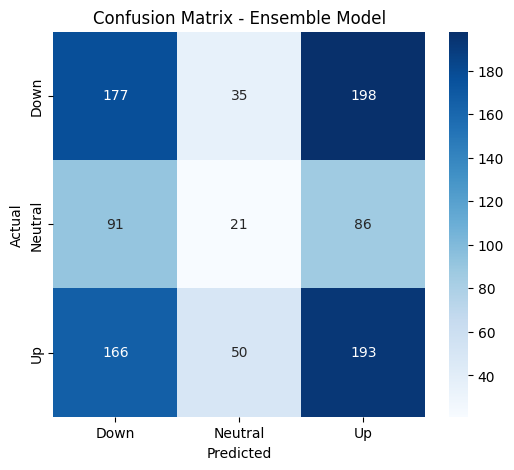

In [29]:
print("📊 RESULTS:")
print(f"LSTM Accuracy:     {(lstm_pred_class == y_test_mapped).mean():.4f}")
print(f"BiLSTM Accuracy:   {(bilstm_pred_class == y_test_mapped).mean():.4f}")
print(f"Ensemble Accuracy: {(ensemble_pred == y_test_mapped).mean():.4f}")

print("\nClassification Report (Ensemble):")
print(classification_report(y_test_mapped, ensemble_pred, target_names=['Down', 'Neutral', 'Up']))

cm = confusion_matrix(y_test_mapped, ensemble_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Neutral', 'Up'],
            yticklabels=['Down', 'Neutral', 'Up'])
plt.title('Confusion Matrix - Ensemble Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 💾 Cell 13: บันทึกโมเดล

In [28]:
os.makedirs('models', exist_ok=True)
lstm_model.save('models/lstm_model.h5')
bilstm_model.save('models/bilstm_model.h5')
joblib.dump(meta_model, 'models/meta_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(selected_feature_names, 'models/feature_names.pkl')

print("✅ All models saved successfully!")
print("🎉 MASTER PIPELINE COMPLETED!")

✅ All models saved successfully!
🎉 MASTER PIPELINE COMPLETED!
